In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

Circuit Depth: 30


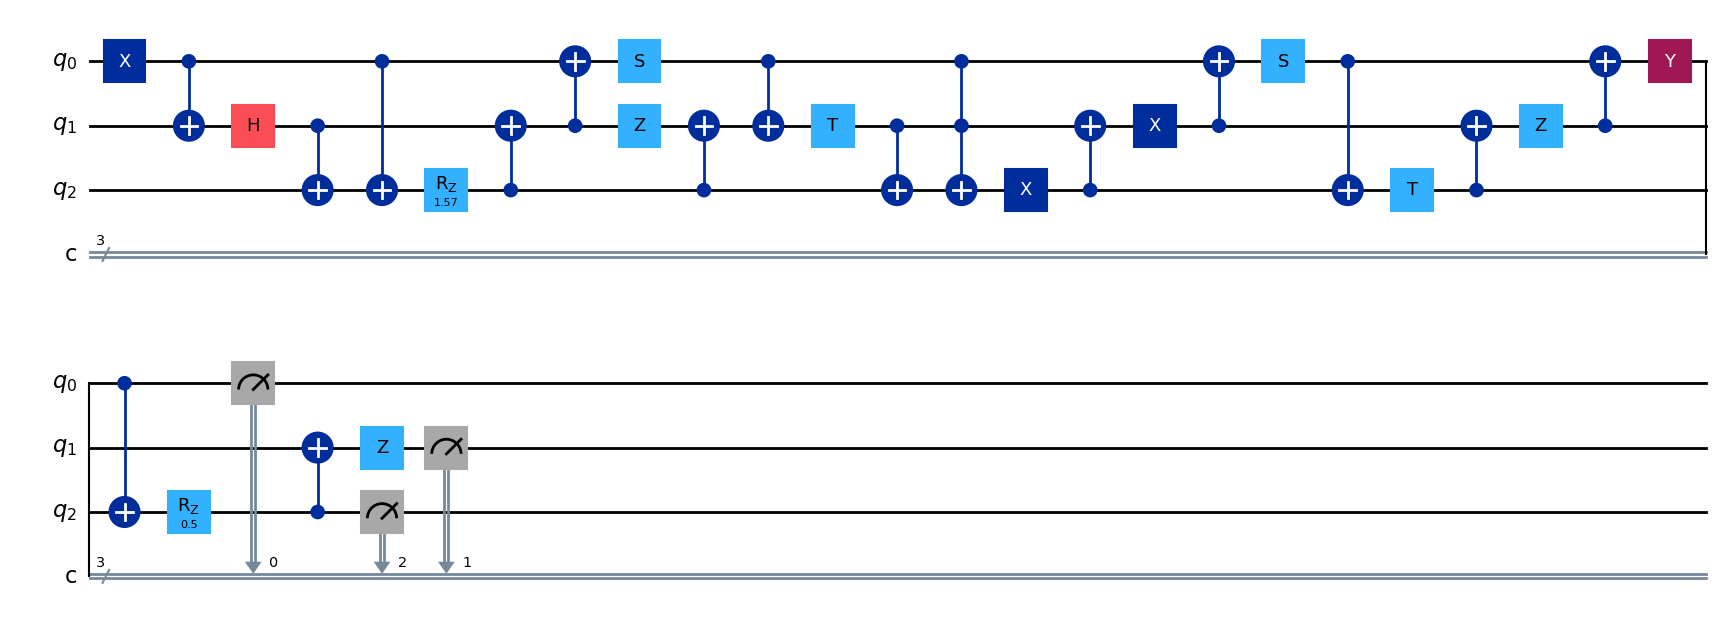

In [2]:
qc = QuantumCircuit(3, 3)

qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.rz(1.57, 2)
qc.cx(2, 1)
qc.cx(1, 0)
qc.z(1)
qc.cx(2, 1)
qc.s(0)
qc.cx(0, 1)
qc.t(1)
qc.cx(1, 2)
qc.ccx(0, 1, 2)
qc.x(2)
qc.cx(2, 1)
qc.x(1)
qc.cx(1, 0)
qc.s(0)
qc.cx(0, 2)
qc.t(2)
qc.cx(2, 1)
qc.z(1)
qc.cx(1, 0)
qc.y(0)
qc.cx(0, 2)
qc.rz(0.5, 2)
qc.cx(2, 1)
qc.z(1)

qc.measure([0, 1, 2], [0, 1, 2])

print(f"Circuit Depth: {qc.depth()}")
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [19]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
print(backend.basis_gates)
print(backend.coupling_map) 
# transpiled_circuit.draw("mpl")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
['cz', 'id', 'rz', 'sx', 'x']
[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [3, 16], [4, 3], [4, 5], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [7, 17], [8, 7], [8, 9], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [11, 18], [12, 11], [12, 13], [13, 12], [13, 14], [14, 13], [14, 15], [15, 14], [15, 19], [16, 3], [16, 23], [17, 7], [17, 27], [18, 11], [18, 31], [19, 15], [19, 35], [20, 21], [21, 20], [21, 22], [21, 36], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 37], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 38], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 34], [33, 39], [34, 33], [34, 35], [35, 19], [35, 34], [36, 21], [36, 41], [37, 25], [37, 45], [38, 29], [38, 49], [39, 33], [39, 53], [40, 41], [41, 3

In [21]:
sampler = Sampler(mode=backend)

experiment_accuracies = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "110" and state != "111":
            acc_sum += count
    accuracy = acc_sum / 1024
    experiment_accuracies.append(accuracy)

print("Average accuracy over 50 runs:", sum(experiment_accuracies) / len(experiment_accuracies))
print("Accuracies for each run:", experiment_accuracies)

Average accuracy over 50 runs: 0.10755859375
Accuracies for each run: [0.107421875, 0.1171875, 0.0986328125, 0.1181640625, 0.109375, 0.123046875, 0.109375, 0.1123046875, 0.1123046875, 0.1083984375, 0.09765625, 0.09765625, 0.119140625, 0.1025390625, 0.103515625, 0.1025390625, 0.10546875, 0.1005859375, 0.1171875, 0.11328125, 0.1240234375, 0.11328125, 0.087890625, 0.0927734375, 0.103515625, 0.111328125, 0.0947265625, 0.10546875, 0.111328125, 0.09765625, 0.1083984375, 0.12109375, 0.107421875, 0.1005859375, 0.1181640625, 0.119140625, 0.1103515625, 0.10546875, 0.111328125, 0.1064453125, 0.0927734375, 0.1025390625, 0.103515625, 0.1181640625, 0.1279296875, 0.09375, 0.099609375, 0.1025390625, 0.1123046875, 0.0986328125]


In [1]:
import numpy as np
errors = [0.107421875, 0.1171875, 0.0986328125, 0.1181640625, 0.109375, 0.123046875, 0.109375, 0.1123046875, 0.1123046875, 0.1083984375, 0.09765625, 0.09765625, 0.119140625, 0.1025390625, 0.103515625, 0.1025390625, 0.10546875, 0.1005859375, 0.1171875, 0.11328125, 0.1240234375, 0.11328125, 0.087890625, 0.0927734375, 0.103515625, 0.111328125, 0.0947265625, 0.10546875, 0.111328125, 0.09765625, 0.1083984375, 0.12109375, 0.107421875, 0.1005859375, 0.1181640625, 0.119140625, 0.1103515625, 0.10546875, 0.111328125, 0.1064453125, 0.0927734375, 0.1025390625, 0.103515625, 0.1181640625, 0.1279296875, 0.09375, 0.099609375, 0.1025390625, 0.1123046875, 0.0986328125]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.10755859375
Standard deviation of errors over 50 runs: 0.008999244658244676
0.1076 ± 0.0025 (95% CI)


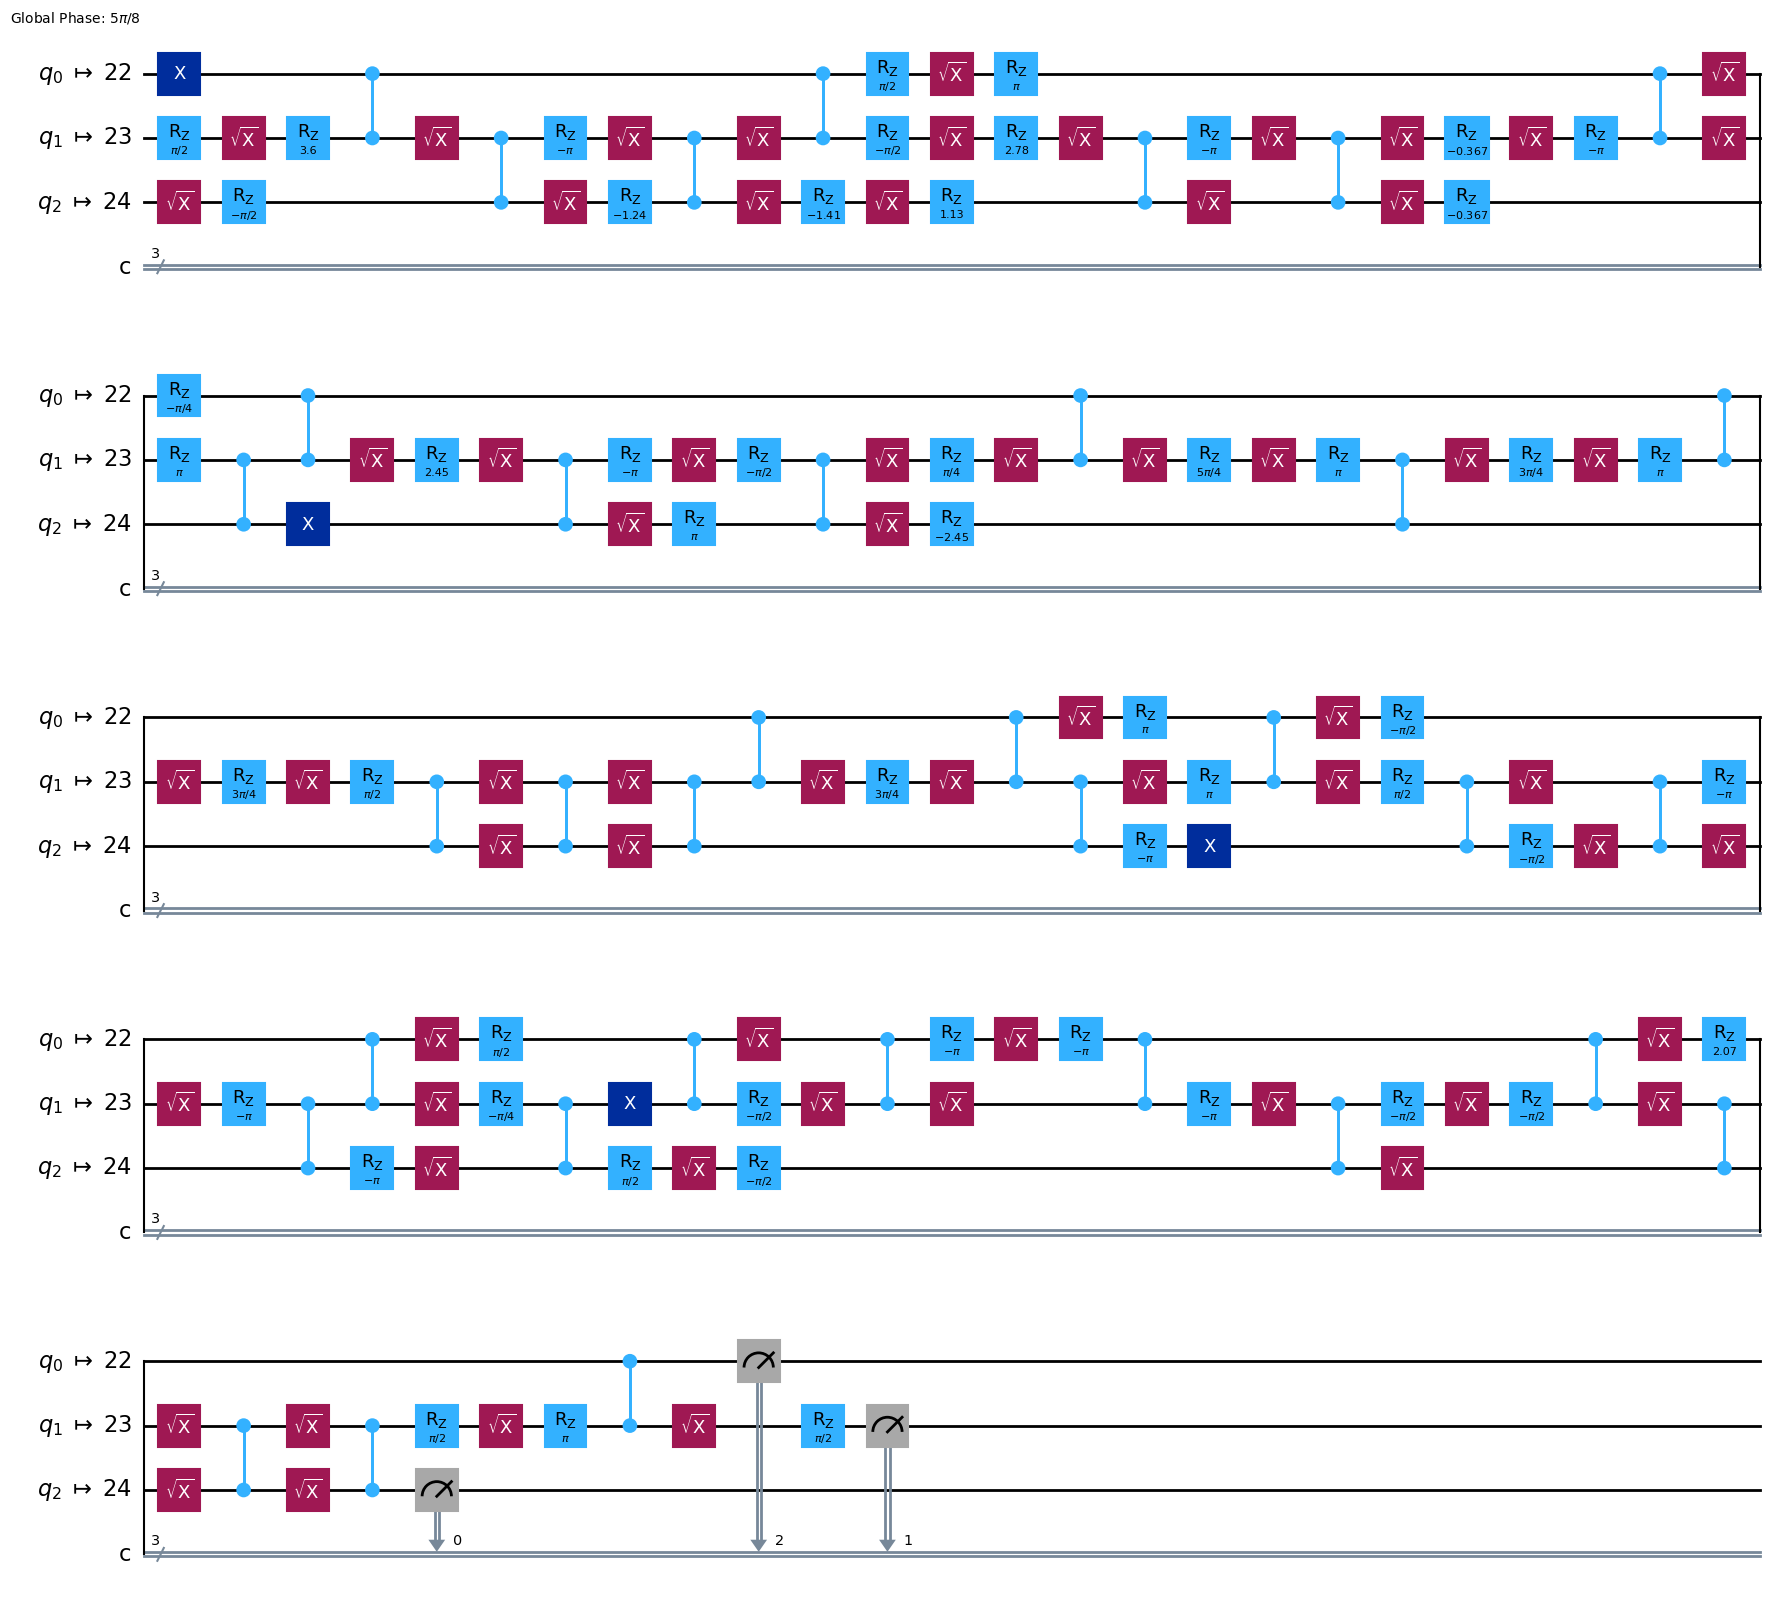

In [23]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [24]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "110" and state != "111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.09099609375
Errors for each run: [0.0849609375, 0.09375, 0.1015625, 0.0947265625, 0.099609375, 0.0869140625, 0.078125, 0.0908203125, 0.087890625, 0.091796875, 0.0908203125, 0.107421875, 0.091796875, 0.0859375, 0.080078125, 0.0791015625, 0.1044921875, 0.0869140625, 0.0908203125, 0.1015625, 0.1083984375, 0.099609375, 0.0947265625, 0.09375, 0.09765625, 0.09765625, 0.091796875, 0.099609375, 0.0830078125, 0.0859375, 0.0869140625, 0.0888671875, 0.091796875, 0.0966796875, 0.072265625, 0.0791015625, 0.08984375, 0.107421875, 0.083984375, 0.0947265625, 0.091796875, 0.0888671875, 0.0966796875, 0.08203125, 0.0859375, 0.08203125, 0.099609375, 0.08984375, 0.0810546875, 0.0791015625]


In [2]:
import numpy as np
errors = [0.0849609375, 0.09375, 0.1015625, 0.0947265625, 0.099609375, 0.0869140625, 0.078125, 0.0908203125, 0.087890625, 0.091796875, 0.0908203125, 0.107421875, 0.091796875, 0.0859375, 0.080078125, 0.0791015625, 0.1044921875, 0.0869140625, 0.0908203125, 0.1015625, 0.1083984375, 0.099609375, 0.0947265625, 0.09375, 0.09765625, 0.09765625, 0.091796875, 0.099609375, 0.0830078125, 0.0859375, 0.0869140625, 0.0888671875, 0.091796875, 0.0966796875, 0.072265625, 0.0791015625, 0.08984375, 0.107421875, 0.083984375, 0.0947265625, 0.091796875, 0.0888671875, 0.0966796875, 0.08203125, 0.0859375, 0.08203125, 0.099609375, 0.08984375, 0.0810546875, 0.0791015625]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.09099609375
Standard deviation of errors over 50 runs: 0.00821634444507039
0.0910 ± 0.0023 (95% CI)


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [25]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 0


In [26]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [27]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7b2hdj0g7hs73dp167g
Job ID: d7b2hdr0g7hs73dp168g
Job ID: d7b2hdu5nvhs73a2p83g
Job ID: d7b2he30g7hs73dp16a0
Job ID: d7b2hee5nvhs73a2p840
Job ID: d7b2hem5nvhs73a2p860
Job ID: d7b2her0g7hs73dp16cg
Job ID: d7b2hf65nvhs73a2p86g
Job ID: d7b2hfb0g7hs73dp16dg
Job ID: d7b2hfm5nvhs73a2p88g


In [28]:
job_ids = [
    "d7b2hdj0g7hs73dp167g",
    "d7b2hdr0g7hs73dp168g",
    "d7b2hdu5nvhs73a2p83g",
    "d7b2he30g7hs73dp16a0",
    "d7b2hee5nvhs73a2p840",
    "d7b2hem5nvhs73a2p860",
    "d7b2her0g7hs73dp16cg",
    "d7b2hf65nvhs73a2p86g",
    "d7b2hfb0g7hs73dp16dg",
    "d7b2hfm5nvhs73a2p88g",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "110" and state != "111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7b2hdj0g7hs73dp167g: error = 0.1406
Job d7b2hdr0g7hs73dp168g: error = 0.1680
Job d7b2hdu5nvhs73a2p83g: error = 0.1523
Job d7b2he30g7hs73dp16a0: error = 0.1484
Job d7b2hee5nvhs73a2p840: error = 0.1670
Job d7b2hem5nvhs73a2p860: error = 0.1660
Job d7b2her0g7hs73dp16cg: error = 0.1533
Job d7b2hf65nvhs73a2p86g: error = 0.1748
Job d7b2hfb0g7hs73dp16dg: error = 0.1543
Job d7b2hfm5nvhs73a2p88g: error = 0.1729

Average error over runs: 0.159765625


Running on: ibm_fez (156 qubits)


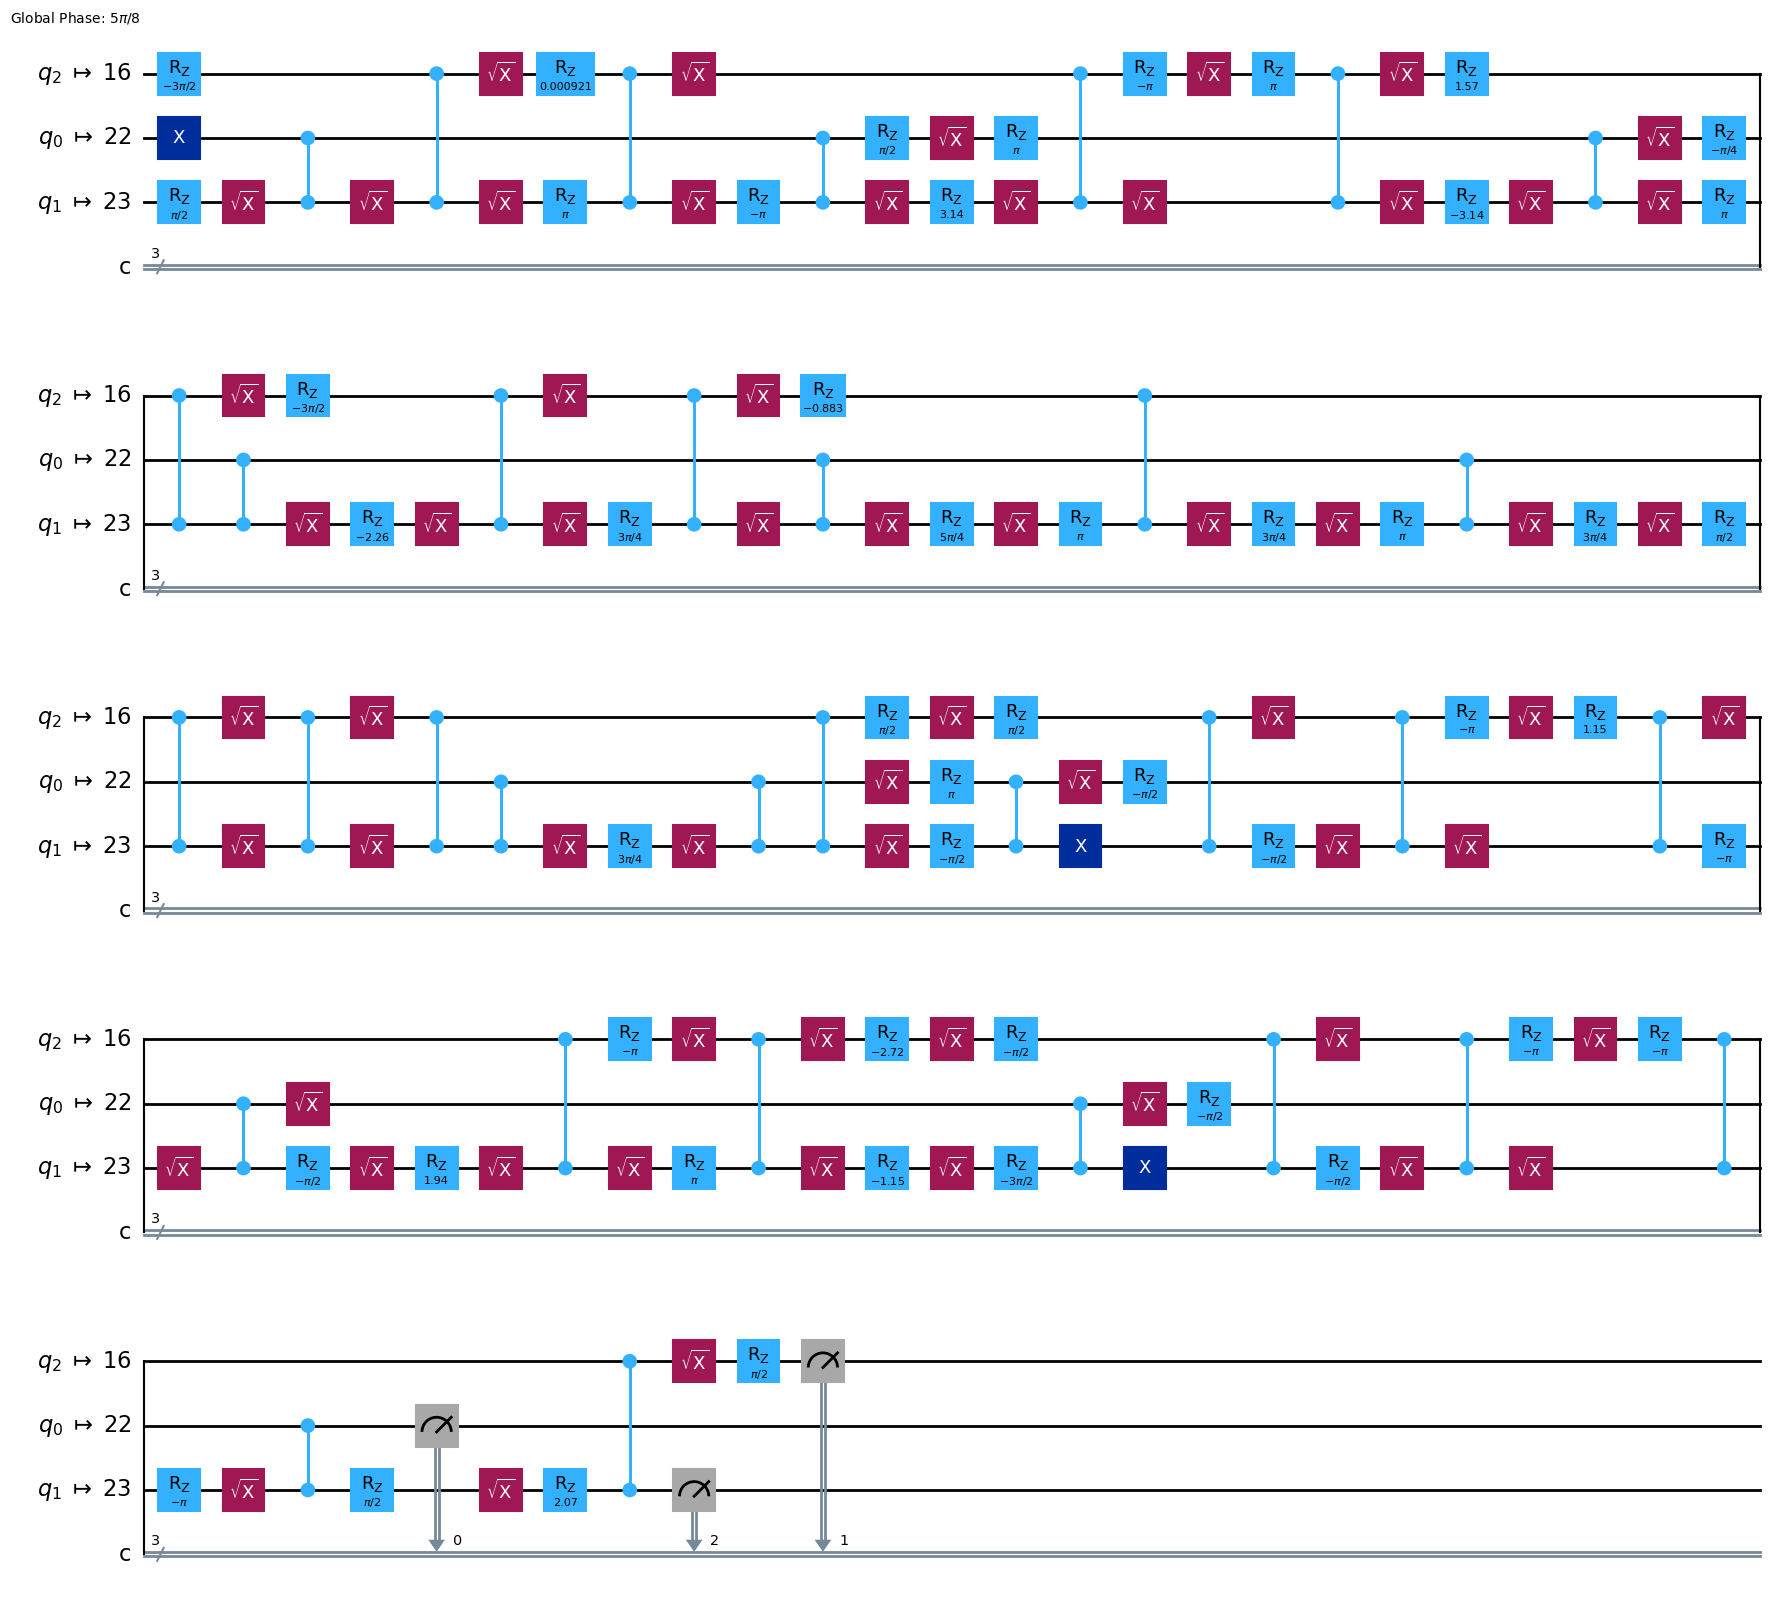

In [29]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [30]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7b2i665nvhs73a2p910
Job ID: d7b2i6b0g7hs73dp17a0
Job ID: d7b2i6j0g7hs73dp17b0
Job ID: d7b2i6u5nvhs73a2p92g
Job ID: d7b2i730g7hs73dp17d0
Job ID: d7b2i7b0g7hs73dp17eg
Job ID: d7b2i7jklj2c73eumahg
Job ID: d7b2i7u5nvhs73a2p94g
Job ID: d7b2i83klj2c73eumaig
Job ID: d7b2i8e5nvhs73a2p95g


In [31]:
job_ids = [
    "d7b2i665nvhs73a2p910",
    "d7b2i6b0g7hs73dp17a0",
    "d7b2i6j0g7hs73dp17b0",
    "d7b2i6u5nvhs73a2p92g",
    "d7b2i730g7hs73dp17d0",
    "d7b2i7b0g7hs73dp17eg",
    "d7b2i7jklj2c73eumahg",
    "d7b2i7u5nvhs73a2p94g",
    "d7b2i83klj2c73eumaig",
    "d7b2i8e5nvhs73a2p95g",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "110" and state != "111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7b2i665nvhs73a2p910: error = 0.1260
Job d7b2i6b0g7hs73dp17a0: error = 0.1357
Job d7b2i6j0g7hs73dp17b0: error = 0.1289
Job d7b2i6u5nvhs73a2p92g: error = 0.1279
Job d7b2i730g7hs73dp17d0: error = 0.1201
Job d7b2i7b0g7hs73dp17eg: error = 0.1260
Job d7b2i7jklj2c73eumahg: error = 0.1191
Job d7b2i7u5nvhs73a2p94g: error = 0.1357
Job d7b2i83klj2c73eumaig: error = 0.1230
Job d7b2i8e5nvhs73a2p95g: error = 0.1221

Average error over runs: 0.12646484375


In [11]:
# Transpile for simulator
simulator = AerSimulator()
from qiskit import transpile
circ = transpile(qc, simulator)

# Run and get counts
result = simulator.run(circ).result()
counts = result.get_counts(circ)
print(counts)

{'110': 513, '111': 511}


In [3]:
import time
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("Original circuit:")
print(f"No. of Gates: {qc.size()}")
print(f"Depth: {qc.depth()}\n")

print("My transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

from qiskit import transpile

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("\nQiskit transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:
No. of Gates: 33
Depth: 30

My transpiler:
No. of Gates: 281
Depth: 169
Transpilation time: 1.9855 seconds

Qiskit transpiler:
No. of Gates: 158
Depth: 111
Transpilation time: 0.0461 seconds


In [4]:
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

transpiled_circuit = transpile(qc, backend)

print("Original circuit:")

twoq = sum(1 for inst in qc.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in qc.data if len(inst.qubits) == 1)

print(f"\nOriginal circuit: {twoq} two-qubit gates, {oneq} single-qubit gates")

print("\nMy transpiler:")
twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)


print("\nQiskit transpiler:")

twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:

Original circuit: 15 two-qubit gates, 17 single-qubit gates

My transpiler:

 39 two-qubit gates, 242 single-qubit gates

Qiskit transpiler:

 35 two-qubit gates, 123 single-qubit gates
